# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

# 3. Локальные модули (Движок)
from core.data import UniversalDataLoader
from core.pipeline import MLPipeline
from core.utils import load_hydra_config
from core.artifacts import ArtifactManager

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
# --- Инициализация Гидры ---
cfg = load_hydra_config()


print(f"Проект: {cfg.project_name} | Режим: Baseline Modeling")

try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: outsource_project_name | Режим: Baseline Modeling


# Data Loading

In [3]:
df = pd.read_parquet(f"{cfg.paths.processed_dir}/df_processedv0.0.pq")

In [4]:
loader = UniversalDataLoader(cfg)
# df = loader.load_data()

# Наш метод get_splits сам разобьет данные согласно config.data.test_size
train_df, val_df, test_df = loader.get_splits(df)

target = cfg.data.tabular.target_col

X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (64789, 19)
Валидационная выборка: (9256, 19)
Тестовая выборка: (18512, 19)


# Baselinge

In [5]:
# 1. Инициализируем наш ООП-менеджер артефактов
tracker = ArtifactManager(cfg)

# 2. Достаем имя эксперимента для режима train
mode_for_exp = cfg.mode.lower() if cfg.mode else "train"
experiment_name = cfg.logging.mlflow.experiments.get(mode_for_exp, "default_experiment")

tracker.set_experiment(experiment_name, artifact_location=tracker.artifact_uri)

# 4. Берем динамический run_name прямо из конфига Hydra
run_name = cfg.run_name

In [6]:
# 5. Открываем сессию через контекстный менеджер нашего трекера
with tracker.start_run(run_name=cfg.run_name):
    print(f"Запуск MLflow Run: {cfg.run_name}")
    
    pipeline = MLPipeline(cfg)
    model = pipeline.train(X_train, y_train, X_val, y_val, save_artifacts=True)
    
    print("Обучение завершено! База данных и артефакты успешно инициализированы.")

Запуск MLflow Run: p_v1.0.0__f_v1.1.0__m_v0.1.0
0:	learn: 0.6891909	test: 0.6895698	best: 0.6895698 (0)	total: 275ms	remaining: 4m 34s
50:	learn: 0.6381492	test: 0.6482022	best: 0.6482022 (50)	total: 4.53s	remaining: 1m 24s
100:	learn: 0.6286957	test: 0.6434596	best: 0.6433942 (99)	total: 8.48s	remaining: 1m 15s
150:	learn: 0.6239064	test: 0.6405630	best: 0.6405630 (150)	total: 12s	remaining: 1m 7s
200:	learn: 0.6196903	test: 0.6390219	best: 0.6390219 (200)	total: 15.4s	remaining: 1m 1s
250:	learn: 0.6087376	test: 0.6358909	best: 0.6358909 (250)	total: 19.9s	remaining: 59.3s
300:	learn: 0.5946231	test: 0.6343037	best: 0.6340596 (291)	total: 24.9s	remaining: 57.9s
350:	learn: 0.5826189	test: 0.6335611	best: 0.6327773 (347)	total: 29.8s	remaining: 55.2s
400:	learn: 0.5729681	test: 0.6345543	best: 0.6327773 (347)	total: 34.6s	remaining: 51.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.632777327
bestIteration = 347

Shrink model to first 348 iterations.
Обучение з

c:\sber_autopodpiska\.venv\lib\site-packages\omegaconf\grammar_visitor.py:253: UserWarning: In the sequence `API_ALLOWED_KEYS,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


# Base analise

In [7]:
# 1. Прогоняем тестовые данные через сохраненный препроцессор
# (Чтобы не писать это руками, в будущем добавим метод evaluate в MLPipeline,
# но для анализа в ноутбуке делаем руками)
X_test_clean = pipeline.preprocessor.transform(X_test)

# 2. Получаем предсказания
preds = model.predict(X_test_clean)

task_type = cfg.task_type
print(f"--- МЕТРИКИ БЕЙЗЛАЙНА ({task_type.upper()}) ---\n")

if task_type in ['binary', 'multiclass']:
    print(classification_report(y_test, preds))

    if hasattr(model, 'predict_proba') and task_type == 'binary':
        probs = model.predict_proba(X_test_clean)[:, 1]
        auc = roc_auc_score(y_test, probs)
        print(f"ROC-AUC Score: {auc:.4f}")

elif task_type == 'regression':
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"RMSE: {np.sqrt(mse):.4f}")
    print(f"R2 Score: {r2:.4f}")

--- МЕТРИКИ БЕЙЗЛАЙНА (BINARY) ---

              precision    recall  f1-score   support

           0       0.98      0.61      0.75     18027
           1       0.04      0.64      0.08       485

    accuracy                           0.61     18512
   macro avg       0.51      0.63      0.42     18512
weighted avg       0.96      0.61      0.74     18512

ROC-AUC Score: 0.6763


# Feature Importance

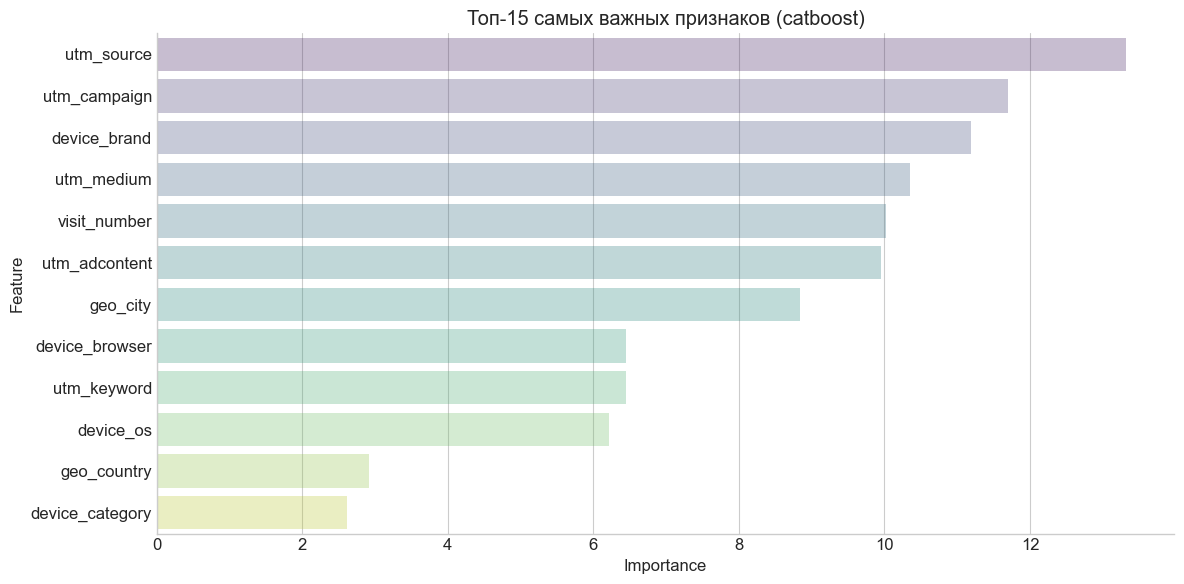

In [9]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure()
    sns.barplot(
        data=fi_df.head(15),  # Показываем топ-15
        x='Importance',
        y='Feature',
        palette='viridis',
        alpha=PLOT_ALPHA
    )
    plt.title(f"Топ-15 самых важных признаков ({cfg.model.name})")
    plt.tight_layout()
    plt.show()
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по Feature Importance

- unique_event_actions - Огромный отрыв, логично что количество уникальных типов действий отражает глубину исследования сервиса. Пользватель который исопльзует много разных инструментов имеет другой паттерн поведения
- car_view_ratio и total_car_views -если пользователь сосредоточен на машинах а не ползает по всему сайту то конверсия возрастает
- visit_number прогрев клиента, чем больше раз заходил тем выше конверсия
- screen_area - возможно влияет адаптированность интерфейса под экран 

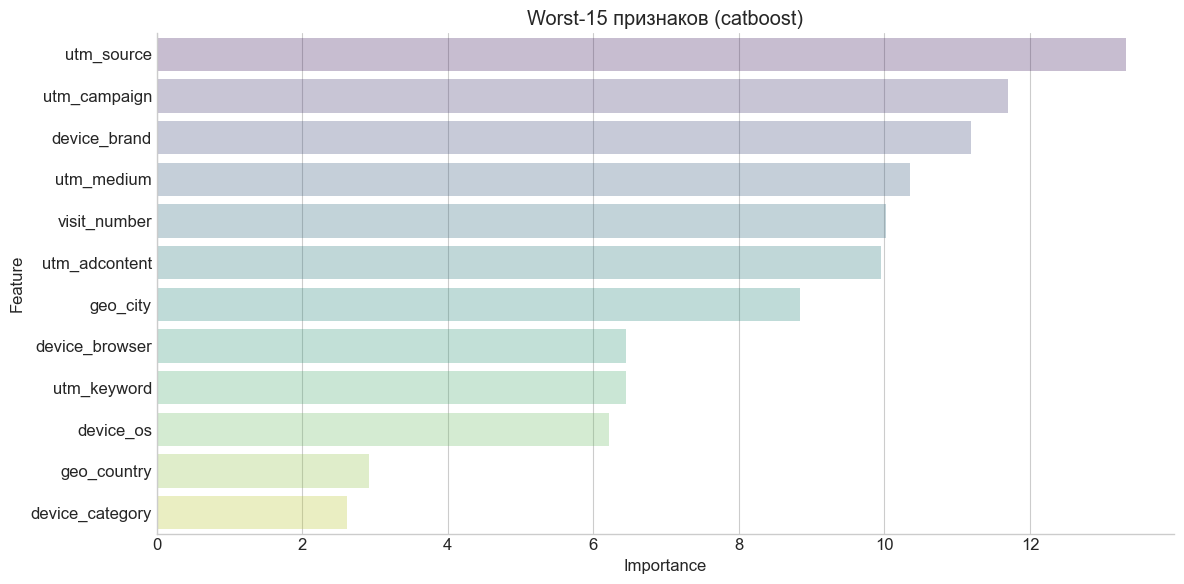

In [10]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure()
    sns.barplot(
        data=fi_df.tail(15),  # Показываем худшие 15
        x='Importance',
        y='Feature',
        palette='viridis',
        alpha=PLOT_ALPHA
    )
    plt.title(f"Worst-15 признаков ({cfg.model.name})")
    plt.tight_layout()
    plt.show()
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по худшим фичам

- geo_country вероятно потому что большая часть всех запросов из России, поэтому этот параметр одинаково влияет как на таргет так и на пустые действия
- geo_zone как производная от geo_country
- is_weekend неожиданно но день недели не влияет на конверсию
- is_first_hit_car_view еще более неожиданно но то откуда пришел клиент по машине или на другую страницу также не сильно влияет на конверсию